# Tutorial 5: scHPF

# Building and visualizing an `ontology` object based on non-negative factors (scHPF)

In this tutorial, we'll demonstrate building and viewing an `ontology` object based on non-negative factors derived from consensus single-cell Hierarchical Poisson Factorization (scHPF). Although the previous tutorials have used bi-directional MOFA factors as input, the `scfo` framework is flexible for annotating and visualizing uni-directional factors as well. We'll use consensus scHPF factors derived from the Tumor population in our GBM atlas.

# Import packages

In [2]:
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import muon as mu
import re
import gseapy as gp
import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import scfo

# Building the Ontology object

**For detailed instructions on how to create the object below, see Tutorial #1: Object Construction**

First we'll load our factors:

In [8]:
all_factors = pd.read_csv('Priors/Tumor_scHPF_factors.csv', index_col = 0).fillna(0)
all_factors.columns = 'Factor' + all_factors.columns.astype(str) + '|Tumor'
all_factors

,Factor0|Tumor,Factor1|Tumor,Factor2|Tumor,Factor3|Tumor,Factor4|Tumor,Factor5|Tumor,Factor6|Tumor,Factor7|Tumor,Factor8|Tumor,Factor9|Tumor,...,Factor16|Tumor,Factor17|Tumor,Factor18|Tumor,Factor19|Tumor,Factor20|Tumor,Factor21|Tumor,Factor22|Tumor,Factor23|Tumor,Factor24|Tumor,Factor25|Tumor
NUPR1,1.304747e-07,0.854638,1.180901,0.000005,0.305347,0.000009,0.000010,0.000018,0.000011,0.239633,...,0.000010,0.000006,0.000004,0.000004,0.000004,0.000005,0.000005,0.000010,0.000006,0.000005
TMEM141,2.050172e-07,0.546738,0.966076,0.000004,0.000028,0.000005,0.000006,0.000008,0.000006,0.000033,...,0.000006,0.000004,0.000003,0.000003,0.000003,0.000004,0.000003,0.000006,0.000004,0.000003
FDXACB1,2.082148e-07,0.558614,0.937355,0.000004,0.000027,0.000005,0.000005,0.000007,0.000005,0.000029,...,0.000005,0.000003,0.000003,0.000003,0.000003,0.000004,0.000003,0.000005,0.000004,0.000003
EEF2KMT,2.131653e-07,0.544586,0.936892,0.000004,0.000026,0.000005,0.000005,0.000007,0.000005,0.000026,...,0.000005,0.000003,0.000003,0.000003,0.000003,0.000004,0.000003,0.000005,0.000004,0.000003
SPHK1,2.164315e-07,0.531810,0.921204,0.000004,0.000023,0.000005,0.000005,0.000007,0.000005,0.000024,...,0.000005,0.000003,0.000003,0.000002,0.000003,0.000004,0.000003,0.000005,0.000004,0.000003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FAM133B,8.799067e+00,8.798588,8.666038,0.000003,0.000014,8.799134,0.000004,0.000006,8.481130,0.000011,...,0.000004,0.000003,0.000002,0.000002,8.726721,0.000003,7.629669,8.679346,0.000003,6.785476
SNTG1,8.799173e+00,0.400184,8.681310,0.000003,0.000005,0.000003,0.000002,0.000005,0.000004,0.000014,...,0.000003,0.000003,0.000002,0.000002,0.000002,0.000003,0.000002,0.000003,0.000003,0.000002
NCAM2,8.799266e+00,0.315843,0.452283,0.000002,0.000009,8.726645,0.000003,7.618112,0.000003,0.000001,...,0.000003,0.000003,0.000002,0.000002,0.000002,8.347485,0.000002,0.000003,0.000003,0.000002
CLASP2,8.799355e+00,0.000186,0.038775,0.000003,0.000008,0.000003,0.000002,0.000006,0.000003,0.000002,...,0.000003,5.724726,0.000002,0.000002,0.000002,0.000002,0.000002,0.000004,0.000003,0.000002


Then we'll load the priors:

In [9]:
all_regulons = pd.read_csv('Priors/all_regulons.csv', index_col = 0).fillna(0)
all_liana = pd.read_csv('Priors/all_liana.csv', index_col = 0).fillna(0)
all_survival_scores = pd.read_csv('Priors/all_surivial_score_loadings.csv', index_col = 0).fillna(0)
all_nichenet = pd.read_csv('Priors/nichenet_downstream.csv', index_col = 0).fillna(0)
all_treatment = pd.read_csv('scfo_input/all_treatment.csv', index_col = 0).fillna(0)

gene_sets = pd.read_csv('Priors/all_signatures.csv')
gene_sets_dict = {}
for sig in gene_sets.columns:
    gene_sets_dict[sig] = list(gene_sets[sig].dropna())

hallmark_lib_dict = gp.get_library(name='MSigDB_Hallmark_2020', organism='Human')

To format the Liana output:

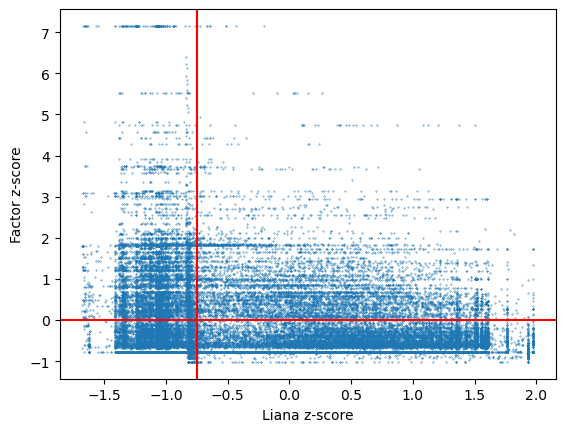

In [11]:
all_liana_send, all_liana_rec, _, _, _ = scfo.make_filtered_lr_signatures(
    liana = all_liana, 
    factor_loadings = all_factors, 
    liana_z_threshold = -0.75, 
    factor_z_threshold = 0, 
    plot_scores = True
)

Now, to build the object:

In [12]:
ontology = scfo.make_ontology(
    factor_loadings=all_factors,
    scored_modalities_ct_aware={
        'regulons': all_regulons,
        'liana_ligand': all_liana_send,
        'liana_receptor': all_liana_rec,
        'slice_treatment': all_treatment,
        'survival_scores': all_survival_scores,
    },
    scored_modalities={
        'nichenet_downstream': all_nichenet,
    },
    gene_set_modalities={
       'hallmark': hallmark_lib_dict,
       'literature': gene_sets_dict,
    },
    n_iter=1000,
)

Permuting for 'nichenet_downstream'...:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating GSEA for 'hallmark'...:   0%|          | 0/26 [00:00<?, ?it/s]

Calculating GSEA for 'literature'...:   0%|          | 0/26 [00:00<?, ?it/s]

Permuting for 'regulons'... [Tumor]:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting for 'liana_ligand'... [Tumor]:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting for 'liana_receptor'... [Tumor]:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting for 'slice_treatment'... [Tumor]:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting for 'survival_scores'... [Tumor]:   0%|          | 0/1000 [00:00<?, ?it/s]

In [13]:
ontology

MuData object with n_obs × n_vars = 26 × 19353
  obs:	'FactorName', 'Classification', 'Number', 'FactorType'
  uns:	'gene_names', 'factor_type', 'modality_names'
  9 modalities
    weights:	26 x 12286
    nichenet_downstream:	26 x 6988
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_names', 'feature_loading_row_axis', 'modality_type'
      varm:	'feature_loadings'
      layers:	'pval'
    hallmark:	26 x 50
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'modality_type', 'gene_sets'
      layers:	'pval'
    literature:	26 x 29
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'modality_type', 'gene_sets'
      layers:	'pval'
    regulons:	26 x 178
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_names', 'feature_loading_row_axis', 'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
      varm:	'feature_loadings'
      layers:	'pval'
    liana_ligand:	26 x 11
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_names', 'feature_loading_row_axis', 'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
      varm:	'feature_loadings'
      layers:	'pval'
    liana_receptor:	26 x 11
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_names', 'feature_loading_row_axis', 'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
      varm:	'feature_loadings'
      layers:	'pval'
    slice_treatment:	26 x 9
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_names', 'feature_loading_row_axis', 'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
      varm:	'feature_loadings'
      layers:	'pval'
    survival_scores:	26 x 10
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_names', 'feature_loading_row_axis', 'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
      varm:	'feature_loadings'
      layers:	'pval'

To save the object:

In [14]:
ontology.write_h5mu('scfo_schpf_gbm_tumor.h5mu')

# Visualizing the Ontology

**For detailed instructions on how to create the plots below, see Tutorial #2: Visualization**

We'll first load our `ontology` object:

In [15]:
ontology = mu.read_h5mu('scfo_schpf_gbm_tumor.h5mu')

Let's visualize the top Tumor factor:

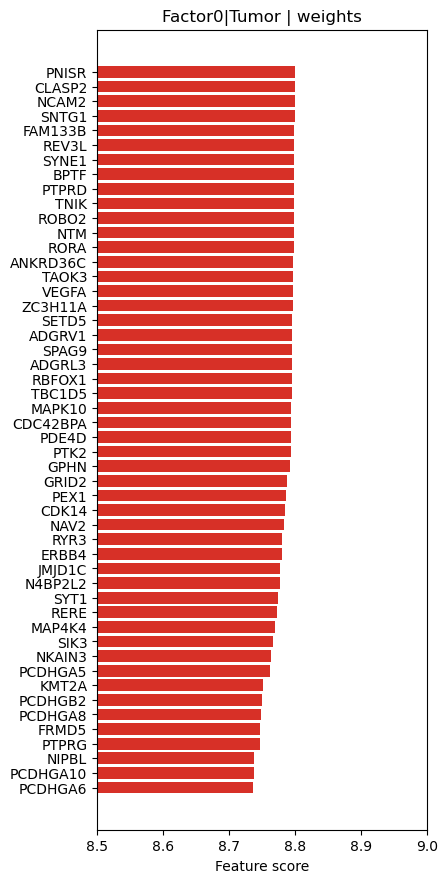

In [29]:
factor = 'Factor0|Tumor'
mod = 'weights'

fig, ax = scfo.plot_factor_top_features(
    ontology,
    factor=factor,
    modality=mod,
    n_pos=50,
    n_neg = 0,
    xlim = (8.5,9),
    figsize = (3.3, 8),
    #path = 'Figures/'+factor+'_'+mod+'.svg'
)

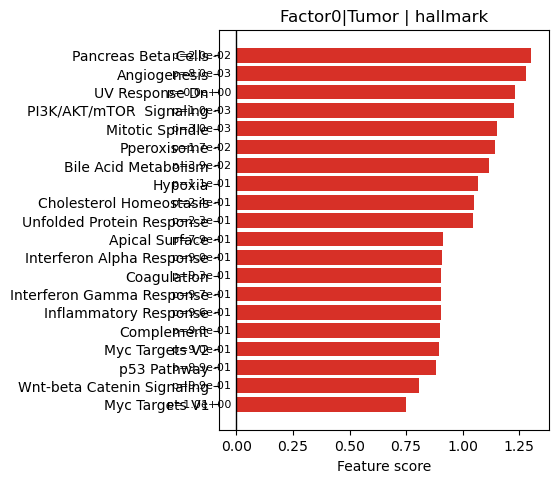

In [17]:
factor = 'Factor0|Tumor'
mod = 'hallmark'

fig, ax = scfo.plot_factor_top_features(
    ontology,
    factor=factor,
    modality=mod,
    n_pos=10,
    n_neg = 10,
    figsize = (3.3, 4),
    #path = 'Figures/'+factor+'_'+mod+'.svg'
)

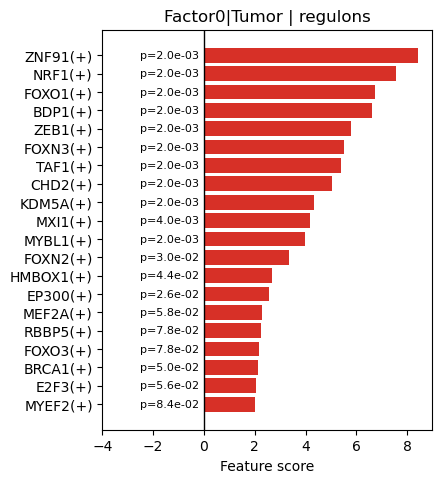

In [32]:
factor = 'Factor0|Tumor'
mod = 'regulons'

fig, ax = scfo.plot_factor_top_features(
    ontology,
    factor=factor,
    modality=mod,
    n_pos=20,
    n_neg = 0,
    xlim = (-4, 9),
    figsize = (3.3, 4),
    #path = 'Figures/'+factor+'_'+mod+'.svg'
)

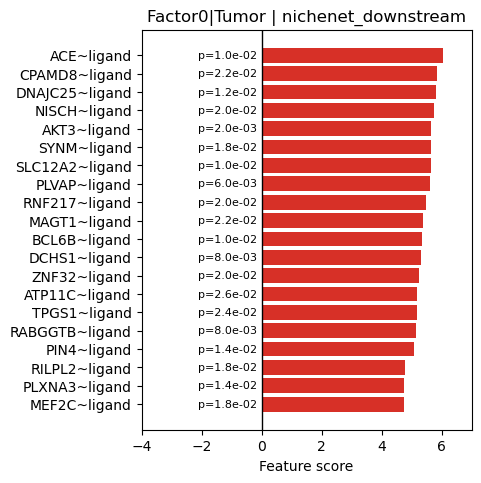

In [34]:
factor = 'Factor0|Tumor'
mod = 'nichenet_downstream'

fig, ax = scfo.plot_factor_top_features(
    ontology,
    factor=factor,
    modality=mod,
    n_pos=20,
    n_neg = 0,
    xlim = (-4, 7),
    figsize = (3.3, 4),
    #path = 'Figures/'+factor+'_'+mod+'.svg'
)

In [35]:
tumor_scores = scfo.modality_scores_to_df(
    ontology=ontology, 
    modality='slice_treatment', 
    cell_types='Tumor'
)

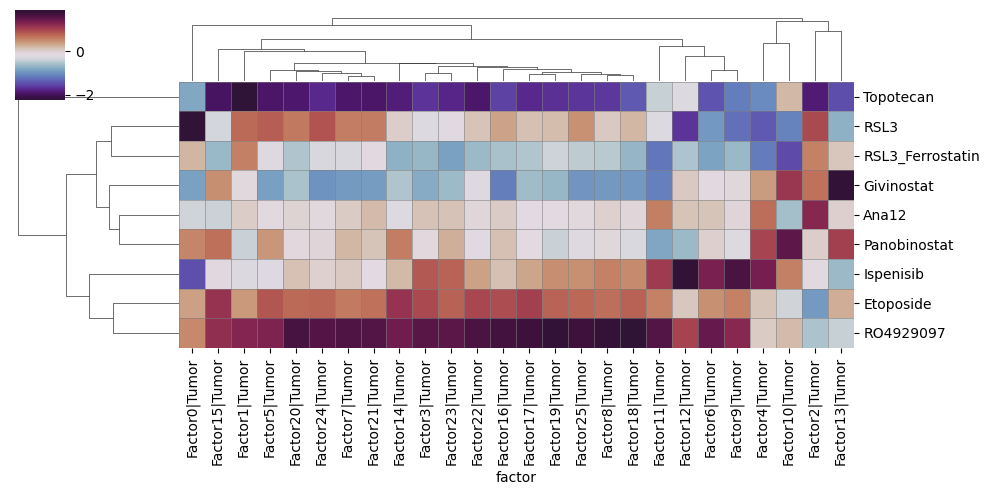

In [36]:
g = sns.clustermap(tumor_scores.T, z_score = 1, cmap = 'twilight_shifted', figsize = (10, 5))
ax = g.ax_heatmap
for x in range(tumor_scores.T.shape[1] + 1):  # columns
    ax.axvline(x, color='grey', linewidth=0.4)

for y in range(tumor_scores.T.shape[0] + 1):  # rows
    ax.axhline(y, color='grey', linewidth=0.4)

Wonderful! Our analysis works for both MOFA and scHPF factors.